# Experiment using Gradient Boosting Trees on MME embeddings (old and new)

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.model_saving import *
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning, build_run_name
from gbmhackathon.training.cv import *
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os, time
from copy import deepcopy
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(32)
torch.get_num_threads()

32

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

## Dataset preparation

In [5]:
ALL_POSSIBLE_EMBS = ["025-03-22_12-27_phikon_emb_V1.pkl",
                    "2025-03-23_18-32_spatial_emb_V1.pkl",
                    "2025-03-30_14-23_clinical_emb_V1.pkl",
                    "2025-04-05_13-40_wes_emb_V1.pkl",
                    "2025-04-26_16-02_connectivities_spatial_V1.pkl",
                    "2025-05-03_10-15_bulk_emb_V1.pkl",
                    "2025-05-04_02-35_scRNA_emb_V1.pkl",
                    "2025-05-25_14-36_new_clinical_emb_V1.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_mds.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_pca.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_umap.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_mds.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_pca.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_umap.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_mds.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_pca.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_umap.pkl",
                    "2025-06-01_15-11_wes_emb_V1_mds.pkl",
                    "2025-06-01_15-11_wes_emb_V1_pca.pkl",
                    "2025-06-01_15-11_wes_emb_V1_umap.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_mds.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_pca.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_umap.pkl",
                    "2025-06-01_21-03_raw_spatial_emb_pca.pkl",
                    "2025-06-01_22-10_raw_spatial_emb_umap.pkl",
                    "2025-06-02_21-09_raw_scRNA_emb_pca.pkl",
                    "2025-06-02_22-50_raw_scRNA_emb_umap.pkl",
                    "embeddings_HnE_OptimusH0.pkl"]

### You can choose any embedding from the above

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"
                }
name_emb_dict_no_foundation = {
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-06-01_18-36_raw_bulk_emb_pca.pkl",
"scRNA":"2025-06-02_21-09_raw_scRNA_emb_pca.pkl"
                }
name_emb_dict_only_foundation = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl", # Needed to retrieve targets, will be removed afterwards
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"
                }
pkl_storage_folder = "embedding_V1"

In [25]:
dataset_only_foundation = PredictiveLearningDataset(name_emb_dict_only_foundation, pkl_storage_folder, device=device, dropout=0.0, normalize=True, remove_clinical=True)
print(f"Dataset size: {len(dataset_only_foundation)}")
BATCH_SIZE = 114 
dataloader_only_foundation = DataLoader(dataset_only_foundation, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset_only_foundation.device))

cas 2 : device reconnu : cuda 
Using device: cuda
dict_keys(['hne', 'spatial', 'bulk', 'scRNA'])
Clinical successfully removed
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247], de

In [26]:
dataset_no_foundation = PredictiveLearningDataset(name_emb_dict_no_foundation, pkl_storage_folder, device=device, dropout=0.0, normalize=True)
print(f"Dataset size: {len(dataset_no_foundation)}")
BATCH_SIZE = 114 
dataloader_no_foundation = DataLoader(dataset_no_foundation, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset_no_foundation.device))

cas 2 : device reconnu : cuda 
Using device: cuda
Normalization applied successfully
Dataset size: 114


In [27]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=0.0, normalize=True)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 114 
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cuda 
Using device: cuda
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247], device='cuda:0')
Normalization applied successfully
Dataset size: 114


### To make a batch of True patient samples only (no dropout)

In [28]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [29]:
# Batch of all true samples (no dropout augmented samples)
batch_all_no_foundation = [dataset_no_foundation.__getitem__(idx) for idx in dataset_no_foundation.ind2patient if 'd' not in dataset_no_foundation.ind2patient[idx]]
batch_all_no_foundation = collate_predictive(batch_all_no_foundation)

In [30]:
# Batch of all true samples (no dropout augmented samples)
batch_all_only_foundation = [dataset_only_foundation.__getitem__(idx) for idx in dataset_only_foundation.ind2patient if 'd' not in dataset_only_foundation.ind2patient[idx]]
batch_all_only_foundation = collate_predictive(batch_all_only_foundation)

In [31]:
Y = batch_all[-2]

In [32]:
y_reg=Y[:,:2]
y_cat=Y[:,2:]

In [33]:
n_splits = 30  # Number of Monte Carlo iterations
test_size = 0.2  # Fraction of data to use for testing in each split
random_state = 6262  # For reproducibility

mc_cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

## Old Framework MME + GBT

In [17]:
model_path = '../saved_models/old_framework_mme.ckpt'
cfg_model_path = '../saved_models/cfg_old_framework_mme.ckpt'
mme_old = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset.device, training=False)

{'net_type': 'mlp', 'device': device(type='cuda'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [18]:
X_old = concat_modality_embeddings(mme_old(batch_all[2]))

In [19]:
train_GBT(mc_cv, X_old, y_reg, y_cat, 'old_mme')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,old_mme_gbt,30,43.365975,0.929691,0.980198,1.034485,0.939886,1.002337,1.064166,0.486942,0.530404,0.565685,0.446674,0.4795,0.514291,1.982535,1.009904,0.230903,0.289476


## Old Framework MME (no Foundation Models modalities) + GBT

In [20]:
model_path = '../saved_models/old_noFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_old_noFoundation_mme.ckpt'
mme_old = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_no_foundation.device, training=False)

Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [21]:
X_old = concat_modality_embeddings(mme_old(batch_all_no_foundation[2]))

In [22]:
train_GBT(mc_cv, X_old, y_reg, y_cat, 'old_mme_noFoundation')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,old_mme_noFoundation_gbt,30,5.160927,0.874912,0.930924,0.988828,0.93375,0.990537,1.051886,0.504506,0.542548,0.58015,0.447325,0.482688,0.515928,1.921461,1.025237,0.241634,0.281549


## Old Framework MME (only Foundation Models modalities) + GBT

In [34]:
model_path = '../saved_models/old_onlyFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_old_onlyFoundation_mme.ckpt'
mme_old = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_only_foundation.device, training=False)

{'net_type': 'mlp', 'device': device(type='cuda'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [35]:
X_old = concat_modality_embeddings(mme_old(batch_all_only_foundation[2]))

In [36]:
train_GBT(mc_cv, X_old, y_reg, y_cat, 'old_mme_onlyFoundation')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,old_mme_onlyFoundation_gbt,30,40.553859,0.973829,1.030126,1.100618,0.977376,1.039757,1.096182,0.500699,0.535544,0.56931,0.454467,0.497893,0.534851,2.069883,1.033438,0.237343,0.289563


## New Framework MME + GBT

In [37]:
model_path = '../saved_models/new_framework_mme.ckpt'
cfg_model_path = '../saved_models/cfg_new_framework_mme.ckpt'
mme_new = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset.device, training=False)

{'net_type': 'mlp', 'device': device(type='cuda'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [38]:
X_new = concat_modality_embeddings(mme_new(batch_all[2]))

In [39]:
train_GBT(mc_cv, X_new, y_reg, y_cat, 'new_mme')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_mme_gbt,30,5.231049,0.938208,0.981982,1.029129,0.931078,0.992234,1.054912,0.4865,0.520136,0.560891,0.404574,0.444008,0.479956,1.974216,0.964144,0.217392,0.312802


## New Framework MME (no Foundation Models modalities) + GBT

In [40]:
model_path = '../saved_models/new_noFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_new_noFoundation_mme.ckpt'
mme_new = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_no_foundation.device, training=False)

Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [41]:
X_new = concat_modality_embeddings(mme_new(batch_all_no_foundation[2]))

In [42]:
train_GBT(mc_cv, X_new, y_reg, y_cat, 'new_mme_noFoundation')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_mme_noFoundation_gbt,30,4.901258,0.906102,0.951679,1.007171,0.902812,0.959967,1.019519,0.48856,0.538957,0.585193,0.444619,0.481834,0.521045,1.911646,1.02079,0.227775,0.337911


## New Framework MME (only Foundation Models modalities) + GBT

In [43]:
model_path = '../saved_models/new_onlyFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_new_onlyFoundation_mme.ckpt'
mme_new = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_only_foundation.device, training=False)

{'net_type': 'mlp', 'device': device(type='cuda'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [44]:
X_new = concat_modality_embeddings(mme_new(batch_all_only_foundation[2]))

In [45]:
train_GBT(mc_cv, X_new, y_reg, y_cat, 'new_mme_onlyFondation')

Iteration 30/30

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_mme_onlyFondation_gbt,30,4.655344,0.991802,1.048533,1.113386,1.000524,1.060333,1.114213,0.548154,0.58318,0.624968,0.459334,0.492383,0.524292,2.108866,1.075563,0.223176,0.263641


## Plot results table

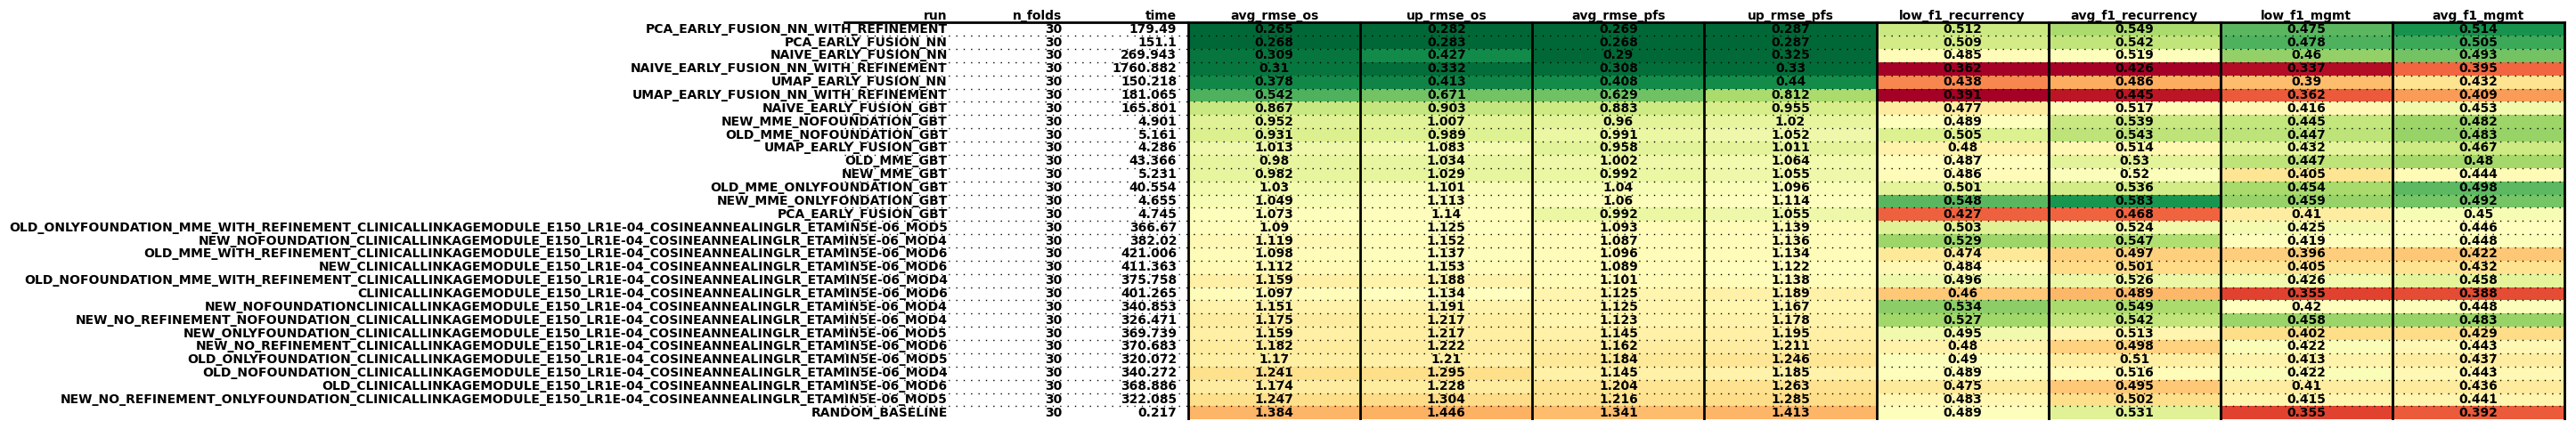

In [46]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")